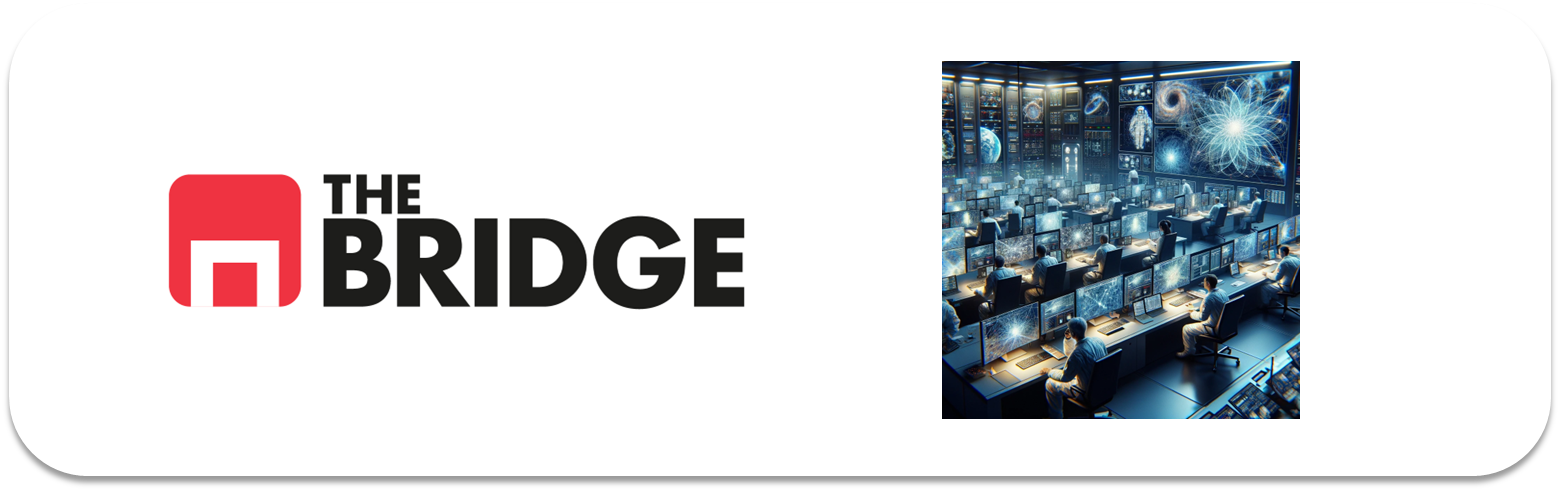

## PRACTICA OBLIGATORIA: **Transfer Learning y Fine Tuning con CNN**

* La práctica obligatoria de esta unidad consiste en un repetir el ejercicio de construcción de un modelo de clasificación de paisajes pero usando un modelo preentrenado. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

### Objetivo del ejercicio

Comparar una red convolucional hecha ad-hoc frente a los modelos preentrenados y ajustados con fine tuning y transfer learning. Para ello emplea el dataset de paisajes del conjunto de ejercicios de la unidad anterior.


### Se pide

1. Preparar los datos del modelo y las funciones de visualización, copia para ello todo lo que necesites de las soluciones del ejercicio de clasificación de paisajes de la unidad anterior.

2. Escoger entre uno de los modelos VGG-19, InceptionV3 y MobileNetV2 (todos en https://keras.io/api/applications/) (Se aconseja este último si no tenemos un ordenador muy potente). Si no te haces con estos puedes recurrir a la ResNetV50.

4. Hacer un transfer-learning con una cabeza de como mucho 2 capas densas ocultas y una de salida. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

5. Hacer un fine-tuning con la misma cabeza diseñada en el punto anterior. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

6. Comparar los resultados con los obtenidos con la red convolucional del ejercicio mencionado.

EXTRA:
- Repetir el transfer learning empleando aumentado de imágenes.



In [26]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from keras.utils import load_img, img_to_array
import kagglehub
import keras
from keras.applications import MobileNetV2
from keras.layers import GlobalAveragePooling2D, Dense, Dropout
from keras.models import Model
from keras.applications.mobilenet_v2 import preprocess_input
from sklearn.utils import shuffle
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [27]:
path = kagglehub.dataset_download("puneet6060/intel-image-classification")
print("Path to dataset files:", path)


Path to dataset files: C:\Users\lupep\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2


In [28]:


BASE_PATH = Path(r"C:\Users\lupep\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2")

# Exploramos la estructura de carpetas
for item in sorted(BASE_PATH.rglob("*")):
    # Mostramos solo directorios para ver la estructura
    if item.is_dir():
        # Calculamos el nivel de profundidad para indentar
        nivel = len(item.relative_to(BASE_PATH).parts)
        print("  " * nivel + item.name)

  seg_pred
    seg_pred
  seg_test
    seg_test
      buildings
      forest
      glacier
      mountain
      sea
      street
  seg_train
    seg_train
      buildings
      forest
      glacier
      mountain
      sea
      street


In [29]:
TRAIN_PATH = BASE_PATH / "seg_train" / "seg_train"
TEST_PATH  = BASE_PATH / "seg_test"  / "seg_test"

# Verificamos que existen
print(TRAIN_PATH.exists())  # debe imprimir True
print(TEST_PATH.exists())   # debe imprimir True

# Clases disponibles
clases = sorted([d.name for d in TRAIN_PATH.iterdir() if d.is_dir()])
print(f"\nClases ({len(clases)}):", clases)

# Número de imágenes por clase en train y test
print("\nImágenes por clase:")
print(f"{'Clase':<12} {'Train':>8} {'Test':>8}")
print("-" * 30)
for clase in clases:
    n_train = len(list((TRAIN_PATH / clase).glob("*.jpg")))
    n_test  = len(list((TEST_PATH  / clase).glob("*.jpg")))
    print(f"{clase:<12} {n_train:>8} {n_test:>8}")

True
True

Clases (6): ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

Imágenes por clase:
Clase           Train     Test
------------------------------
buildings        2191      437
forest           2271      474
glacier          2404      553
mountain         2512      525
sea              2274      510
street           2382      501


Mapeo clases: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}
Cargando train...
  Leyendo buildings: 2191 imágenes...
  Leyendo forest: 2271 imágenes...
  Leyendo glacier: 2404 imágenes...
  Leyendo mountain: 2512 imágenes...
  Leyendo sea: 2274 imágenes...
  Leyendo street: 2382 imágenes...

Cargando test...
  Leyendo buildings: 437 imágenes...
  Leyendo forest: 474 imágenes...
  Leyendo glacier: 553 imágenes...
  Leyendo mountain: 525 imágenes...
  Leyendo sea: 510 imágenes...
  Leyendo street: 501 imágenes...

X_train shape: (14034, 64, 64, 3)
y_train shape: (14034,)
X_test shape:  (3000, 64, 64, 3)
y_test shape:  (3000,)

=== MINI EDA ===
Total imágenes train: 14034
Total imágenes test:  3000
Clases: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Rango píxeles: [0.0, 255.0]


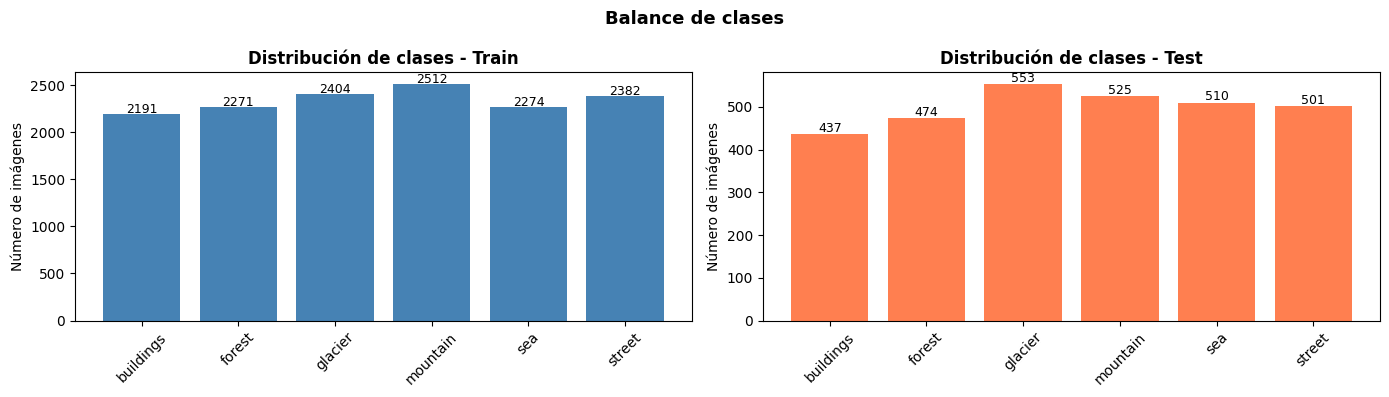

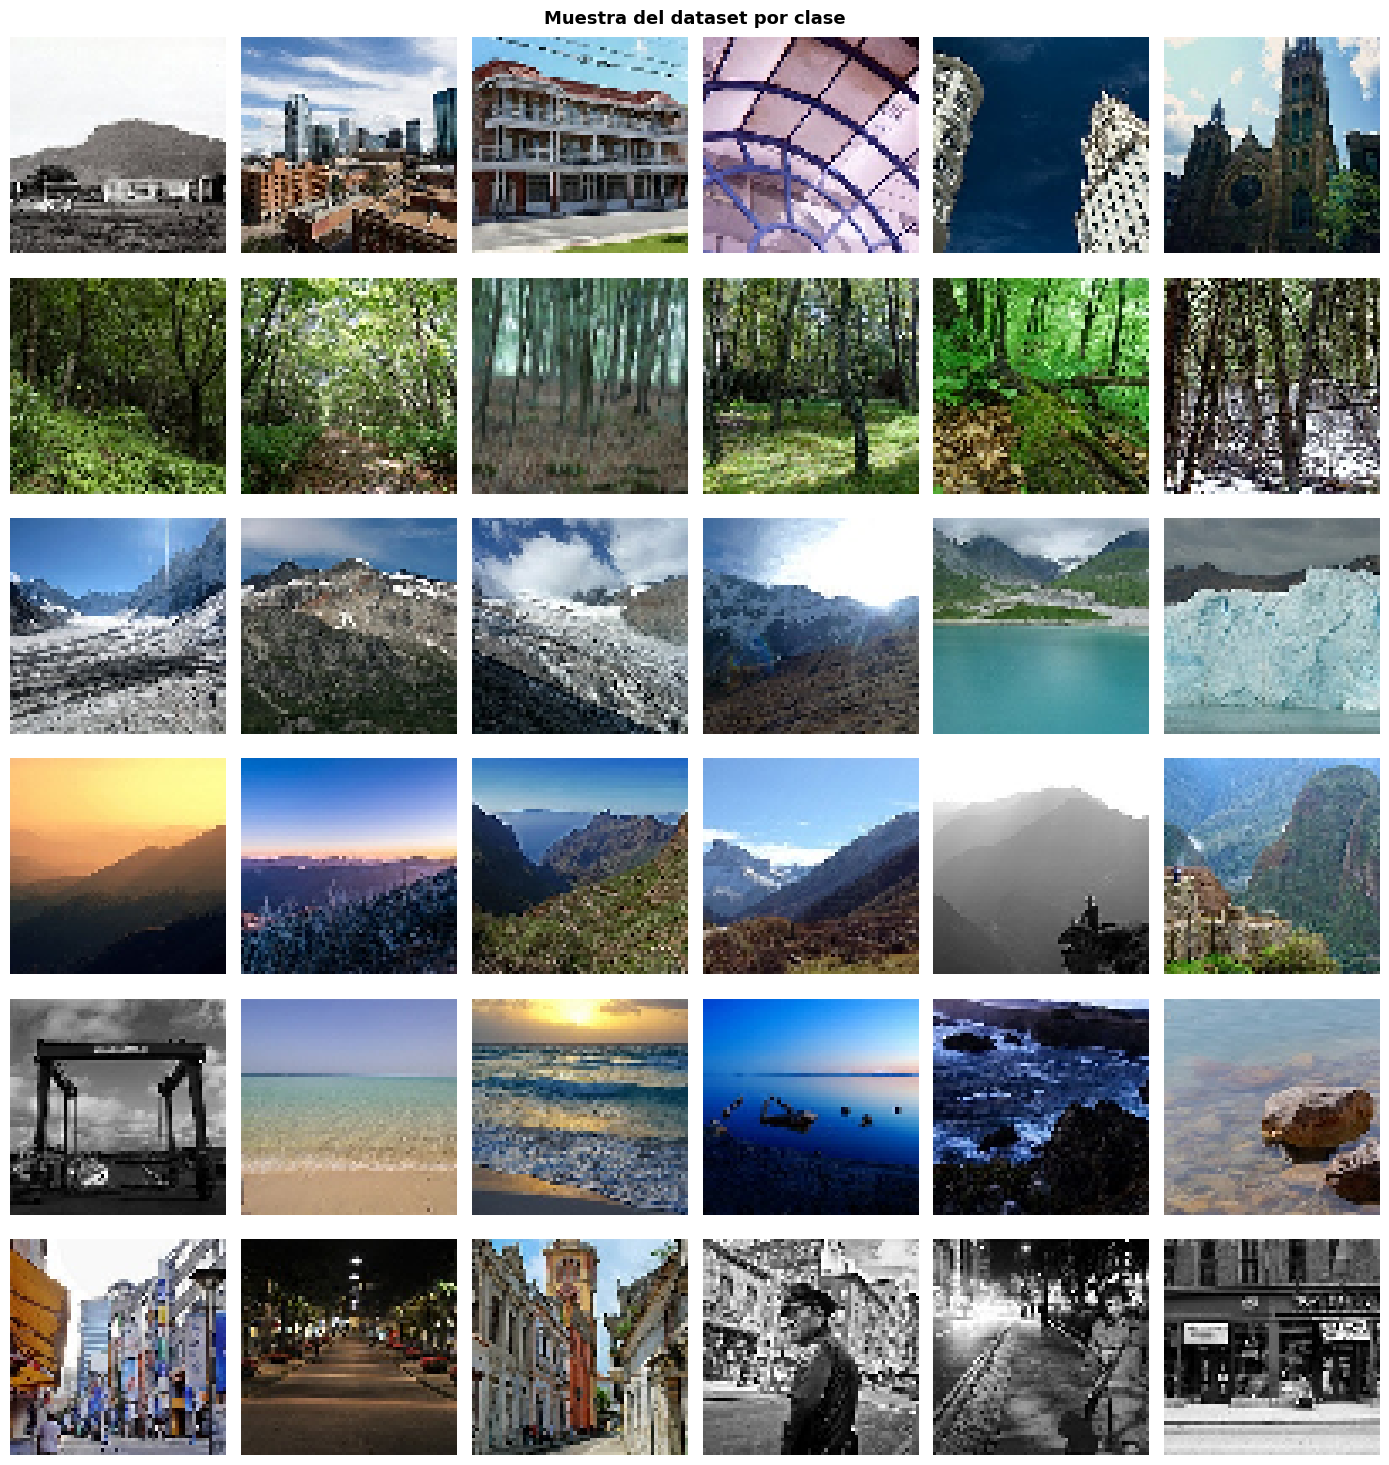

In [30]:
IMG_SIZE = 64  # usamos 64x64 en vez de 32x32, los paisajes tienen más detalle

# Diccionario clase → índice numérico
class_to_idx = {clase: idx for idx, clase in enumerate(clases)}
idx_to_class = {idx: clase for clase, idx in class_to_idx.items()}
print("Mapeo clases:", class_to_idx)


# =============================================================
# FUNCIÓN DE CARGA
# =============================================================
def cargar_dataset(base_path, clases, img_size=64):
    """
    Lee todas las imágenes de un directorio organizado por subcarpetas de clase.
    La clase viene dada por el nombre de la carpeta, no del archivo.
    """
    imagenes  = []
    etiquetas = []
    
    for clase in clases:
        clase_path = base_path / clase
        archivos   = list(clase_path.glob("*.jpg"))
        
        print(f"  Leyendo {clase}: {len(archivos)} imágenes...")
        
        for filepath in archivos:
            try:
                img = load_img(filepath,
                               target_size=(img_size, img_size),
                               color_mode='rgb')
                img = img_to_array(img)
                imagenes.append(img)
                etiquetas.append(class_to_idx[clase])
            except Exception as e:
                print(f"     Error leyendo {filepath.name}: {e}")
    
    return np.array(imagenes), np.array(etiquetas)


# =============================================================
# CARGA TRAIN Y TEST
# =============================================================
print("Cargando train...")
X_train, y_train = cargar_dataset(TRAIN_PATH, clases, IMG_SIZE)

print("\nCargando test...")
X_test, y_test = cargar_dataset(TEST_PATH, clases, IMG_SIZE)

print(f"\nX_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_test shape:  {y_test.shape}")


# =============================================================
# NORMALIZACIÓN
# =============================================================
X_train_norm = X_train / 255.0
X_test_norm  = X_test  / 255.0


# =============================================================
# MINI EDA
# =============================================================
print("\n=== MINI EDA ===")
print(f"Total imágenes train: {len(X_train)}")
print(f"Total imágenes test:  {len(X_test)}")
print(f"Clases: {clases}")
print(f"Rango píxeles: [{X_train.min()}, {X_train.max()}]")

# Balance de clases
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

counts_train = [(y_train == i).sum() for i in range(len(clases))]
counts_test  = [(y_test  == i).sum() for i in range(len(clases))]

axes[0].bar(clases, counts_train, color='steelblue')
axes[0].set_title('Distribución de clases - Train', fontweight='bold')
axes[0].set_ylabel('Número de imágenes')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(counts_train):
    axes[0].text(i, v + 10, str(v), ha='center', fontsize=9)

axes[1].bar(clases, counts_test, color='coral')
axes[1].set_title('Distribución de clases - Test', fontweight='bold')
axes[1].set_ylabel('Número de imágenes')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(counts_test):
    axes[1].text(i, v + 5, str(v), ha='center', fontsize=9)

plt.suptitle('Balance de clases', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


# =============================================================
# VISUALIZACIÓN DE MUESTRAS POR CLASE
# =============================================================
fig, axes = plt.subplots(len(clases), 6, figsize=(14, len(clases)*2.5))

for i, clase in enumerate(clases):
    indices = np.where(y_train == class_to_idx[clase])[0][:6]
    for j, idx in enumerate(indices):
        axes[i, j].imshow(X_train[idx].astype('uint8'))
        if j == 0:
            axes[i, j].set_ylabel(clase, fontsize=10,
                                   fontweight='bold', rotation=90)
        axes[i, j].axis('off')

plt.suptitle('Muestra del dataset por clase', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [31]:
# =============================================================
# Recargar imágenes a 96x96 para MobileNetV2
# =============================================================
IMG_SIZE = 96

print("Recargando train a 96x96...")
X_train_96, y_train = cargar_dataset(TRAIN_PATH, clases, IMG_SIZE)

print("\nRecargando test a 96x96...")
X_test_96, y_test = cargar_dataset(TEST_PATH, clases, IMG_SIZE)

print(f"\nX_train shape: {X_train_96.shape}")
print(f"X_test shape:  {X_test_96.shape}")

# Normalización
X_train_norm = X_train_96 / 255.0
X_test_norm  = X_test_96  / 255.0

Recargando train a 96x96...
  Leyendo buildings: 2191 imágenes...
  Leyendo forest: 2271 imágenes...
  Leyendo glacier: 2404 imágenes...
  Leyendo mountain: 2512 imágenes...
  Leyendo sea: 2274 imágenes...
  Leyendo street: 2382 imágenes...

Recargando test a 96x96...
  Leyendo buildings: 437 imágenes...
  Leyendo forest: 474 imágenes...
  Leyendo glacier: 553 imágenes...
  Leyendo mountain: 525 imágenes...
  Leyendo sea: 510 imágenes...
  Leyendo street: 501 imágenes...

X_train shape: (14034, 96, 96, 3)
X_test shape:  (3000, 96, 96, 3)


In [32]:
base_model = MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=(96, 96, 3)   # ← ahora sí es un tamaño válido
)
base_model.trainable = False

inputs  = keras.Input(shape=(96, 96, 3))
x       = base_model(inputs, training=False)
x       = GlobalAveragePooling2D()(x)
x       = Dense(128, activation='relu')(x)
x       = Dropout(0.3)(x)
outputs = Dense(6, activation='softmax')(x)

model_tl = Model(inputs, outputs)

model_tl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Parámetros entrenables:  {sum([p.numpy().size for p in model_tl.trainable_weights])}")
print(f"Parámetros congelados:   {sum([p.numpy().size for p in model_tl.non_trainable_weights])}")

model_tl.summary()

Parámetros entrenables:  164742
Parámetros congelados:   2257984


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# =============================================================
# FASE 1 - Transfer Learning puro (solo entrenamos la cabeza)
# =============================================================

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("FASE 1: Entrenando solo la cabeza clasificadora...")
print(f"Parámetros entrenables: 164.742 (cabeza)")
print(f"Parámetros congelados:  2.257.984 (MobileNetV2)\n")

history_fase1 = model_tl.fit(
    X_train_norm,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

# --- Gráficas fase 1 ---
def plot_training_history(history, titulo='Evolución del entrenamiento'):
    loss_train = history.history['loss']
    loss_val   = history.history['val_loss']
    acc_train  = history.history['accuracy']
    acc_val    = history.history['val_accuracy']

    epocas     = range(1, len(loss_train) + 1)
    best_epoch = loss_val.index(min(loss_val)) + 1

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epocas, loss_train, 'b-o', markersize=4, label='Train loss')
    ax1.plot(epocas, loss_val,   'r-o', markersize=4, label='Validación loss')
    ax1.axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.7,
                label=f'Mejor época ({best_epoch})')
    ax1.set_title('Evolución del Loss', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epocas, acc_train, 'b-o', markersize=4, label='Train accuracy')
    ax2.plot(epocas, acc_val,   'r-o', markersize=4, label='Validación accuracy')
    ax2.axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.7,
                label=f'Mejor época ({best_epoch})')
    ax2.set_title('Evolución del Accuracy', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Época')
    ax2.set_ylabel('Accuracy')
    ax2.set_ylim([0, 1])
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.suptitle(titulo, fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"\n{'='*45}")
    print(f"  Épocas entrenadas:       {len(loss_train)}")
    print(f"  Mejor época (val_loss):  {best_epoch}")
    print(f"  Mejor val_loss:          {min(loss_val):.4f}")
    print(f"  Mejor val_accuracy:      {max(acc_val):.4f}  ({max(acc_val)*100:.2f}%)")
    print(f"{'='*45}")

plot_training_history(history_fase1, 'Fase 1: Transfer Learning')

FASE 1: Entrenando solo la cabeza clasificadora...
Parámetros entrenables: 164.742 (cabeza)
Parámetros congelados:  2.257.984 (MobileNetV2)

Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.8798 - loss: 0.3424 - val_accuracy: 0.1393 - val_loss: 10.0730
Epoch 2/20
 90/351 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.9095 - loss: 0.2504

Rango píxeles ANTES: [0.0, 255.0]
Rango píxeles DESPUÉS: [-1.00, 1.00]

FASE 1: Reentrenando con preprocesamiento correcto...
Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - accuracy: 0.8870 - loss: 0.3123 - val_accuracy: 0.1432 - val_loss: 8.4597
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.9280 - loss: 0.2015 - val_accuracy: 0.1489 - val_loss: 11.0292
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.9409 - loss: 0.1639 - val_accuracy: 0.1418 - val_loss: 12.0578
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 18s 50ms/step - accuracy: 0.9492 - loss: 0.1410 - val_accuracy: 0.1450 - val_loss: 15.5649
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 18s 50ms/step - accuracy: 0.9527 - loss: 0.1249 - val_accuracy: 0.1429 - val_loss: 17.0493
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 18s 50ms/step - accuracy: 0.9619 - loss: 0.1010 - val_accuracy: 0.1436 - val_loss: 18.3499
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.


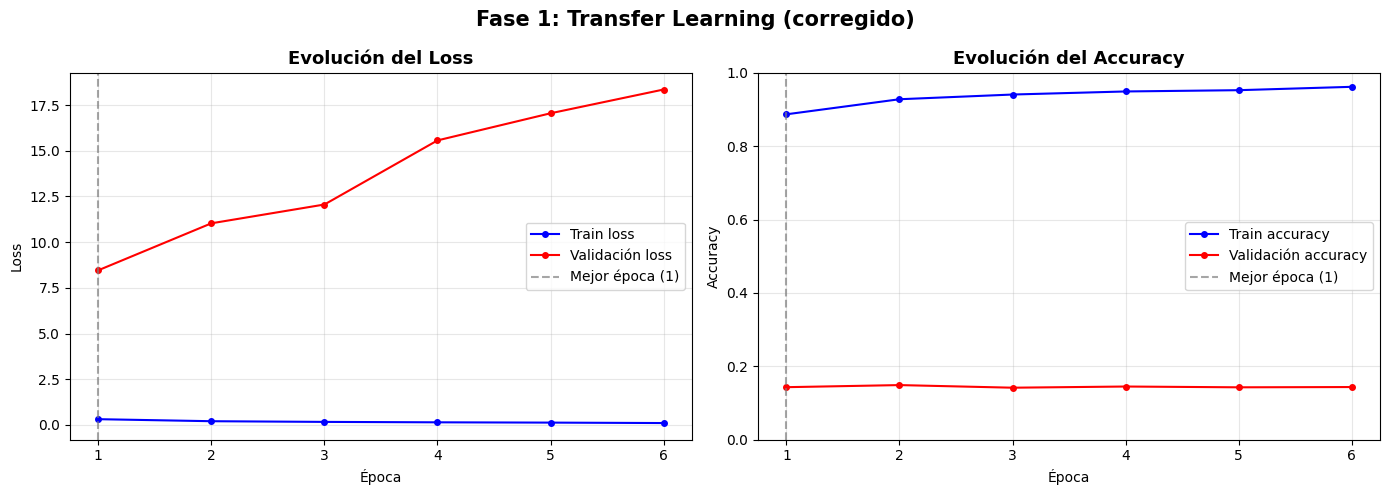


  Épocas entrenadas:       6
  Mejor época (val_loss):  1
  Mejor val_loss:          8.4597
  Mejor val_accuracy:      0.1489  (14.89%)


In [ ]:
# =============================================================
# CORRECCIÓN: Preprocesamiento específico de MobileNetV2
# =============================================================
# preprocess_input de MobileNetV2 convierte píxeles [0,255] → [-1, 1]
# Esto es OBLIGATORIO cuando usamos pesos preentrenados de ImageNet

X_train_prep = preprocess_input(X_train_96.copy())
X_test_prep  = preprocess_input(X_test_96.copy())

print(f"Rango píxeles ANTES: [{X_train_96.min()}, {X_train_96.max()}]")
print(f"Rango píxeles DESPUÉS: [{X_train_prep.min():.2f}, {X_train_prep.max():.2f}]")

# Redefinimos el modelo desde cero
base_model = MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=(96, 96, 3)
)
base_model.trainable = False

inputs  = keras.Input(shape=(96, 96, 3))
x       = base_model(inputs, training=False)
x       = GlobalAveragePooling2D()(x)
x       = Dense(128, activation='relu')(x)
x       = Dropout(0.3)(x)
outputs = Dense(6, activation='softmax')(x)

model_tl = Model(inputs, outputs)

model_tl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Reentrenamos con el preprocesamiento correcto
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("\nFASE 1: Reentrenando con preprocesamiento correcto...")

history_fase1 = model_tl.fit(
    X_train_prep,   # ← ahora con preprocess_input
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

plot_training_history(history_fase1, 'Fase 1: Transfer Learning (corregido)')

In [ ]:
# =============================================================
# DIAGNÓSTICO
# =============================================================

# 1. ¿Las etiquetas están bien?
print("Etiquetas únicas:", np.unique(y_train))
print("Distribución:", {i: (y_train==i).sum() for i in range(6)})

# 2. ¿Las imágenes tienen el rango correcto tras preprocess_input?
print(f"\nRango X_train_prep: [{X_train_prep.min():.2f}, {X_train_prep.max():.2f}]")

# 3. ¿El modelo predice algo con sentido antes de entrenar?
pred_test = model_tl.predict(X_train_prep[:10], verbose=0)
print("\nPredicciones primeras 10 imágenes (probabilidades):")
print(np.round(pred_test, 3))
print("Clases predichas:", np.argmax(pred_test, axis=1))
print("Clases reales:   ", y_train[:10])

# 4. ¿El loss inicial tiene sentido?
# Para 6 clases balanceadas el loss inicial debería ser ~log(6) ≈ 1.79
# Si es 8.4 algo está muy mal
import numpy as np
print(f"\nLoss esperado al azar: {np.log(6):.4f}")
print(f"Loss obtenido:         8.4685  ← MUY alto, algo falla")

Etiquetas únicas: [0 1 2 3 4 5]
Distribución: {0: np.int64(2191), 1: np.int64(2271), 2: np.int64(2404), 3: np.int64(2512), 4: np.int64(2274), 5: np.int64(2382)}

Rango X_train_prep: [-1.00, 1.00]

Predicciones primeras 10 imágenes (probabilidades):
[[0.676 0.006 0.02  0.206 0.09  0.001]
 [0.999 0.    0.    0.001 0.    0.   ]
 [1.    0.    0.    0.    0.    0.   ]
 [0.854 0.007 0.019 0.002 0.116 0.001]
 [0.478 0.005 0.145 0.077 0.294 0.001]
 [0.998 0.001 0.    0.001 0.    0.   ]
 [0.999 0.    0.001 0.    0.    0.   ]
 [1.    0.    0.    0.    0.    0.   ]
 [1.    0.    0.    0.    0.    0.   ]
 [0.999 0.    0.    0.    0.001 0.   ]]
Clases predichas: [0 0 0 0 0 0 0 0 0 0]
Clases reales:    [0 0 0 0 0 0 0 0 0 0]

Loss esperado al azar: 1.7918
Loss obtenido:         8.4685  ← MUY alto, algo falla


Distribución primeras 20 etiquetas ANTES de mezclar: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Distribución primeras 20 etiquetas DESPUÉS de mezclar: [0 5 5 4 3 2 3 3 0 5 0 3 5 4 2 4 4 5 1 3]

FASE 1: Entrenando con datos mezclados...
Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accuracy: 0.8718 - loss: 0.3533 - val_accuracy: 0.9188 - val_loss: 0.2389
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.9169 - loss: 0.2271 - val_accuracy: 0.9170 - val_loss: 0.2332
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 18s 50ms/step - accuracy: 0.9302 - loss: 0.1853 - val_accuracy: 0.9152 - val_loss: 0.2328
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - accuracy: 0.9410 - loss: 0.1541 - val_accuracy: 0.9141 - val_loss: 0.2350
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 16s 44ms/step - accuracy: 0.9515 - loss: 0.1302 - val_accuracy: 0.9198 - val_loss: 0.2439
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - accuracy: 0.9575 - loss: 0.1113 - val_accuracy: 0.9184 - va

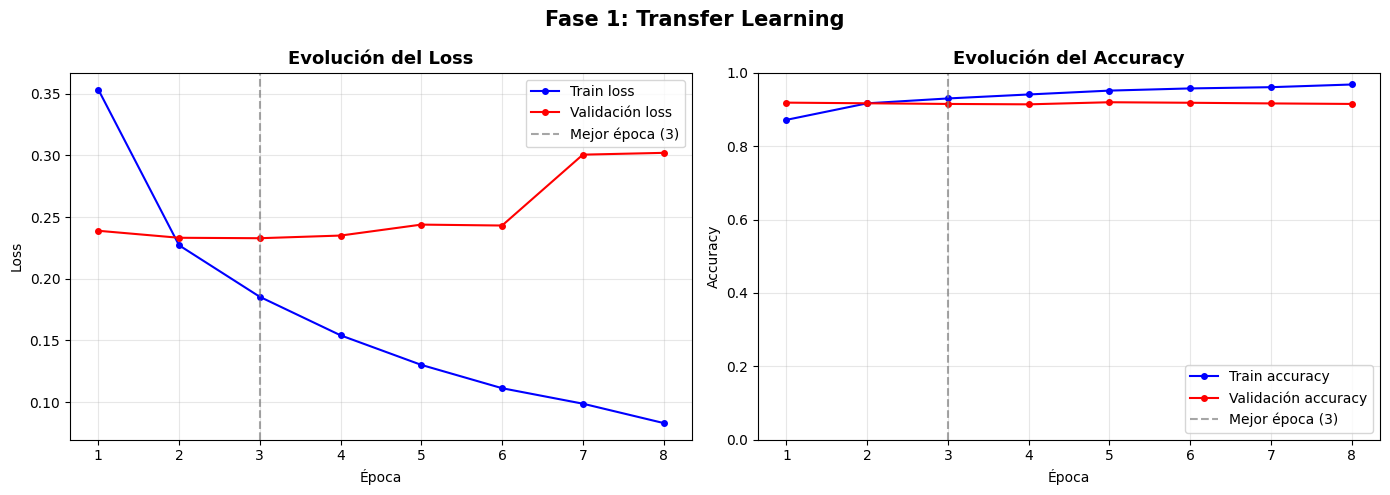


  Épocas entrenadas:       8
  Mejor época (val_loss):  3
  Mejor val_loss:          0.2328
  Mejor val_accuracy:      0.9198  (91.98%)


In [ ]:


# =============================================================
# SOLUCIÓN: Mezclar los datos antes de entrenar
# =============================================================

# Los datos están ordenados por clase: primero todos los buildings,
# luego todos los forests... validation_split coge el 20% final
# que son casi todo streets. Hay que mezclarlos.

X_train_prep_shuf, y_train_shuf = shuffle(X_train_prep, y_train, random_state=42)

print("Distribución primeras 20 etiquetas ANTES de mezclar:", y_train[:20])
print("Distribución primeras 20 etiquetas DESPUÉS de mezclar:", y_train_shuf[:20])

# Redefinimos el modelo desde cero
base_model = MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=(96, 96, 3)
)
base_model.trainable = False

inputs  = keras.Input(shape=(96, 96, 3))
x       = base_model(inputs, training=False)
x       = GlobalAveragePooling2D()(x)
x       = Dense(128, activation='relu')(x)
x       = Dropout(0.3)(x)
outputs = Dense(6, activation='softmax')(x)

model_tl = Model(inputs, outputs)

model_tl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("\nFASE 1: Entrenando con datos mezclados...")

history_fase1 = model_tl.fit(
    X_train_prep_shuf,   # ← datos mezclados
    y_train_shuf,        # ← etiquetas mezcladas
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

plot_training_history(history_fase1, 'Fase 1: Transfer Learning')

Total capas en el modelo base: 154
Parámetros entrenables ahora: 1,691,142
Parámetros congelados ahora:  731,584

FASE 2: Fine Tuning (últimas 30 capas descongeladas)...
Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 23s 55ms/step - accuracy: 0.8415 - loss: 0.4644 - val_accuracy: 0.9106 - val_loss: 0.2656
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step - accuracy: 0.8981 - loss: 0.2795 - val_accuracy: 0.9116 - val_loss: 0.2612
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - accuracy: 0.9099 - loss: 0.2436 - val_accuracy: 0.9120 - val_loss: 0.2557
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step - accuracy: 0.9204 - loss: 0.2176 - val_accuracy: 0.9145 - val_loss: 0.2552
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.9336 - loss: 0.1825 - val_accuracy: 0.9156 - val_loss: 0.2484
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step - accuracy: 0.9368 - loss: 0.1717 - val_accuracy: 0.9159 - val_loss: 0.2498
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/s

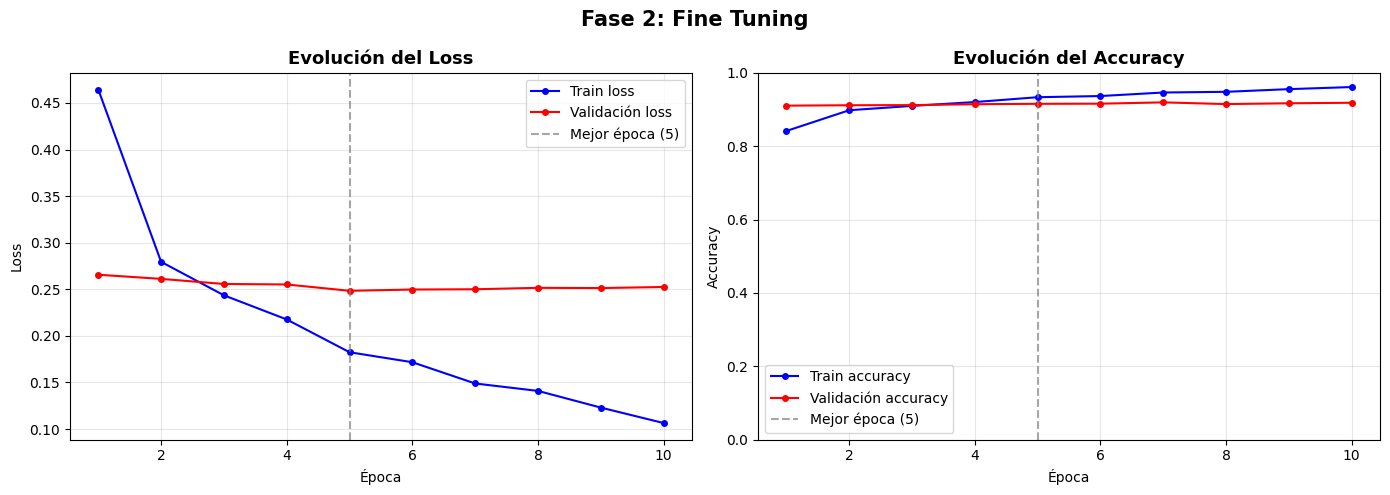


  Épocas entrenadas:       10
  Mejor época (val_loss):  5
  Mejor val_loss:          0.2484
  Mejor val_accuracy:      0.9195  (91.95%)


In [ ]:
# =============================================================
# FASE 2 - Fine Tuning
# Descongelamos las últimas capas de MobileNetV2
# =============================================================

print(f"Total capas en el modelo base: {len(base_model.layers)}")

# Descongelamos el modelo base
base_model.trainable = True

# Pero solo entrenamos las últimas 30 capas
# Las primeras capas detectan patrones muy genéricos (bordes, texturas)
# que ya son útiles tal cual. Las últimas capas son más específicas
# y son las que queremos ajustar a nuestros paisajes.
for layer in base_model.layers[:-30]:
    layer.trainable = False

entrenables = sum([p.numpy().size for p in model_tl.trainable_weights])
congelados  = sum([p.numpy().size for p in model_tl.non_trainable_weights])
print(f"Parámetros entrenables ahora: {entrenables:,}")
print(f"Parámetros congelados ahora:  {congelados:,}")

# IMPORTANTE: en Fine Tuning usamos un learning rate MUY pequeño
# Si usamos el mismo que antes (0.001) destruiríamos los pesos
# preentrenados que ya funcionan bien. Con 0.00001 los ajustamos
# suavemente sin perder lo aprendido.
model_tl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping_ft = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("\nFASE 2: Fine Tuning (últimas 30 capas descongeladas)...")

history_fase2 = model_tl.fit(
    X_train_prep_shuf,
    y_train_shuf,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping_ft],
    verbose=1
)

plot_training_history(history_fase2, 'Fase 2: Fine Tuning')

  Loss en test:      0.2526
  Accuracy en test:  0.9117  (91.17%)

Classification Report:
              precision    recall  f1-score   support

   buildings       0.92      0.90      0.91       437
      forest       0.99      1.00      0.99       474
     glacier       0.88      0.80      0.84       553
    mountain       0.83      0.89      0.86       525
         sea       0.94      0.95      0.95       510
      street       0.92      0.95      0.93       501

    accuracy                           0.91      3000
   macro avg       0.91      0.91      0.91      3000
weighted avg       0.91      0.91      0.91      3000



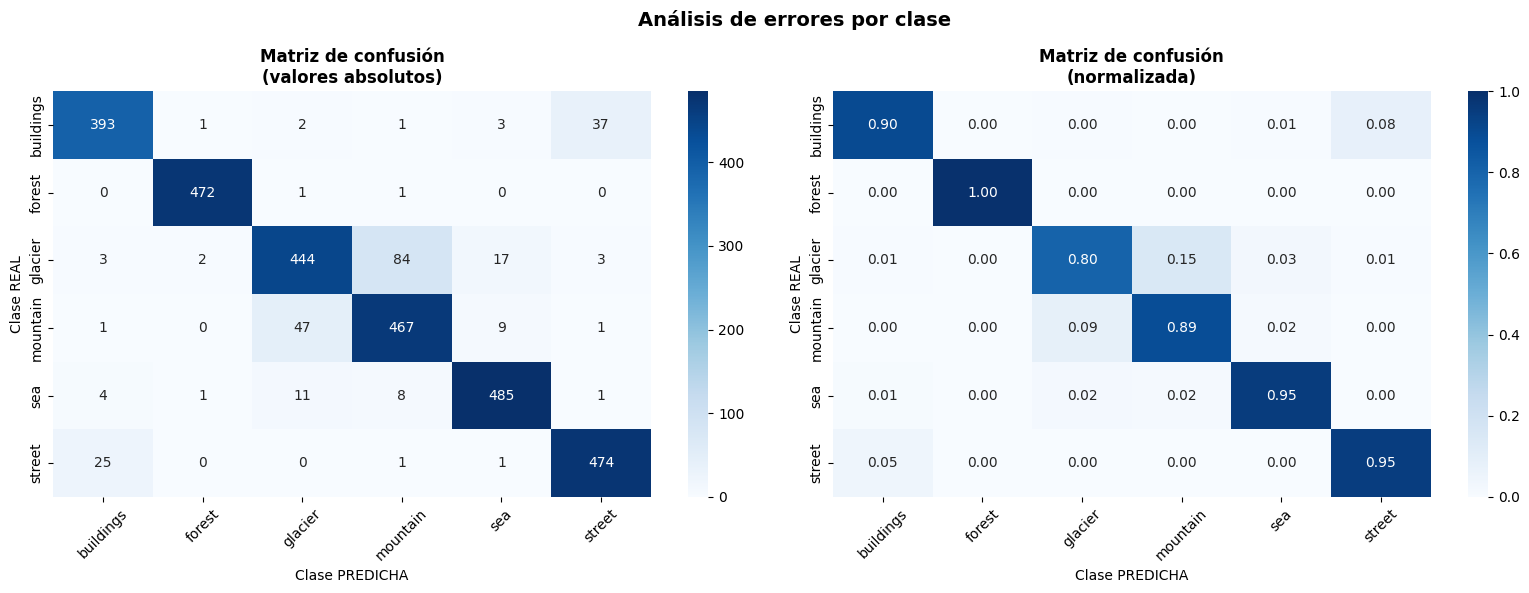


=== Principales confusiones ===
Clase real   → Confundida con   % errores
----------------------------------------
buildings    → street             8.5%
glacier      → mountain          15.2%
mountain     → glacier            9.0%
street       → buildings          5.0%

Total errores: 265 de 3000 (8.8%)


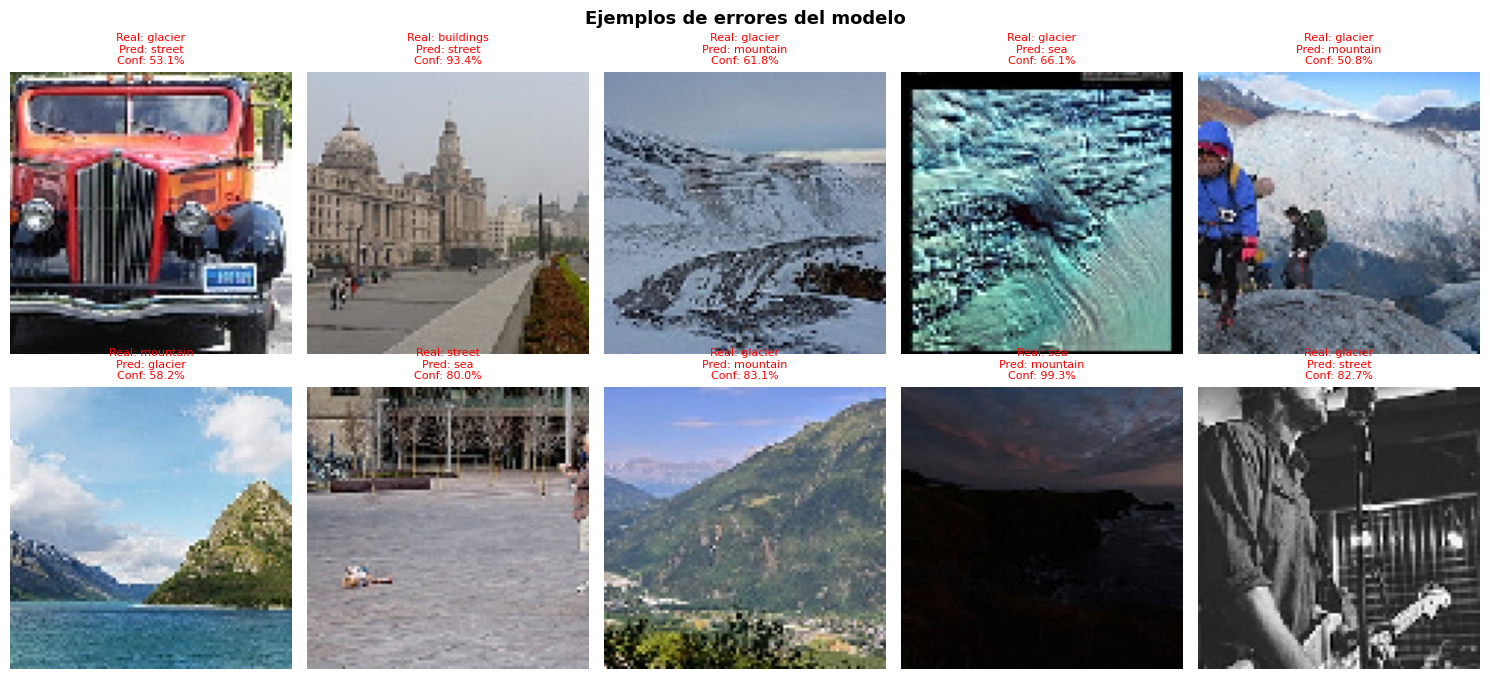

In [ ]:

# EVALUACIÓN FINAL SOBRE TEST

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Preprocesamos el test igual que el train
X_test_prep = preprocess_input(X_test_96.copy())

# Evaluación global
test_loss, test_acc = model_tl.evaluate(X_test_prep, y_test, verbose=0)
print(f"{'='*45}")
print(f"  Loss en test:      {test_loss:.4f}")
print(f"  Accuracy en test:  {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"{'='*45}")

# Predicciones
probabilidades = model_tl.predict(X_test_prep, verbose=0)
predicciones   = np.argmax(probabilidades, axis=1)
confianza      = np.max(probabilidades, axis=1)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, predicciones, target_names=clases))

# Matriz de confusión
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[0], annot_kws={'size': 10})
    axes[0].set_title('Matriz de confusión\n(valores absolutos)',
                      fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Clase REAL')
    axes[0].set_xlabel('Clase PREDICHA')
    axes[0].tick_params(axis='x', rotation=45)

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[1], vmin=0, vmax=1, annot_kws={'size': 10})
    axes[1].set_title('Matriz de confusión\n(normalizada)',
                      fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Clase REAL')
    axes[1].set_xlabel('Clase PREDICHA')
    axes[1].tick_params(axis='x', rotation=45)

    plt.suptitle('Análisis de errores por clase', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Principales confusiones
    print("\n=== Principales confusiones ===")
    print(f"{'Clase real':<12} → {'Confundida con':<12}  {'% errores':>10}")
    print("-" * 40)
    for i in range(len(class_names)):
        fila = cm_norm[i].copy()
        fila[i] = 0
        j = np.argmax(fila)
        if fila[j] > 0.03:
            print(f"{class_names[i]:<12} → {class_names[j]:<12}  {fila[j]*100:>8.1f}%")

plot_confusion_matrix(y_test, predicciones, clases)

# Visualización de algunos errores
indices_errores = np.where(predicciones != y_test)[0]
print(f"\nTotal errores: {len(indices_errores)} de {len(y_test)} ({len(indices_errores)/len(y_test)*100:.1f}%)")

muestra_errores = np.random.choice(indices_errores, size=10, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
axes = axes.flatten()

for i, idx in enumerate(muestra_errores):
    # Desnormalizamos para mostrar la imagen correctamente
    img = (X_test_96[idx]).astype('uint8')
    axes[i].imshow(img)
    axes[i].set_title(
        f"Real: {clases[y_test[idx]]}\n"
        f"Pred: {clases[predicciones[idx]]}\n"
        f"Conf: {confianza[idx]*100:.1f}%",
        fontsize=8, color='red'
    )
    axes[i].axis('off')

plt.suptitle('Ejemplos de errores del modelo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()